In [46]:
import numpy as np
import ultraplot as uplt
import xarray as xr
import cartopy.crs as ccrs
import pandas as pd
import geopandas as gpd
from shapely.geometry import shape
from rasterio.features import shapes
from affine import Affine
from rasterio.features import rasterize
import xarray as xr
import cartopy.feature as cfeature
from numpy import ma 
from scipy.interpolate import interp1d
from matplotlib.colors import Normalize
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.legend_handler import HandlerLine2D

import rioxarray


uplt.rc.style='seaborn-v0_8-paper'
uplt.rc.update({'tick.len': 2.0, 'tick.dir': 'in', 'font.largesize': 12, 'font.smallsize': 10})

In [47]:
def get_da(arr):
    # Load latitude and longitude coordinate data from files
    lats = np.load("/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv-5/lats_737.npy")
    lons = np.load("/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv-5/lons_737.npy")
    
    # Create DataFrame with values and coordinates, then pivot to 2D grid format
    df_pivot = pd.DataFrame({'values': arr, 'lat': lats, 'lon': lons}).pivot_table(
        index='lat', columns='lon', values='values')
    
    # Convert DataFrame to xarray DataArray with proper dimensions and coordinates
    da = xr.DataArray(df_pivot, dims=('lat', 'lon'), 
                     coords={'lat': df_pivot.index, 'lon': df_pivot.columns})
    
    return da

In [48]:
# Load latitude and longitude coordinate data from files
lats = np.load("/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv-5/lats_737.npy")
lons = np.load("/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv-5/lons_737.npy")

# Load upwind overlap data for December-January-February (DJF) season
send_dfj = np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/eg_upwind_overlap_lai_djf.npy')
# Load masked upwind mean data for DJF season
receive_dfj = np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/eg_upwind_masked_lai_dfj_mean-1.npy')

# Load upwind overlap data for June-July-August (JJA) season
send_jja = np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/eg_upwind_overlap_lai_jja.npy')
# Load masked upwind mean data for JJA season
receive_jja = np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/eg_upwind_masked_lai_jja_mean-1.npy')

In [49]:
# Convert DJF season send/upwind overlap data to xarray DataArray with spatial coordinates
da_send_dfj = get_da(arr=send_dfj)

# Convert DJF season receive/masked upwind mean data to xarray DataArray with spatial coordinates
da_receive_dfj = get_da(arr=receive_dfj)

# Convert JJA season send/upwind overlap data to xarray DataArray with spatial coordinates
da_send_jja = get_da(arr=send_jja)

# Convert JJA season receive/masked upwind mean data to xarray DataArray with spatial coordinates
da_receive_jja = get_da(arr=receive_jja)

In [50]:
# Set longitude and latitude boundaries for the map region
lonlim = (-82, -32)
latlim = (-60, 15)

# Load geography regions shapefile for background mapping
geography_shapefile = "/Net/Groups/BGI/work_3/ML4HES/sjiang/plot_exercise/downwind/ne_10m_geography_regions_polys.shp"
geography_vector = gpd.read_file(geography_shapefile)

# Load Amazon basin shapefile for regional highlighting
amazon_shapefile = "/Net/Groups/BGI/work_3/ML4HES/sjiang/plot_exercise/downwind/amazonia_polygons.shp"
amazon_vector = gpd.read_file(amazon_shapefile)

# (Commented out) Alternative: filter for specific Amazon region and dissolve boundaries
# amazon_vector = amazon_vector[amazon_vector['name'] == 'Amazonia - sensu stricto'].dissolve()

# Dissolve all Amazon polygons into a single unified polygon
amazon_vector = amazon_vector.dissolve()
# Extract the dissolved Amazon border for plotting
amazon_border = amazon_vector.loc[[0]]

In [51]:
# import xarray as xr
# ds=xr.open_dataset('era5_850hpa_wind_1d00_monthly.nc')
# djf = ds.sel(valid_time=ds['valid_time'].dt.month.isin([12, 1, 2]))
# jja = ds.sel(valid_time=ds['valid_time'].dt.month.isin([6, 7, 8]))

# # djf_mean_v=djf.v.sel(pressure_level=850).mean(dim='valid_time')
# # djf_mean_v.to_netcdf('era5_850hpa_v_djf_1d00_monthly.nc')

# djf_mean_u=djf.u.sel(pressure_level=850).mean(dim='valid_time')
# djf_mean_u.to_netcdf('era5_850hpa_u_djf_1d00_monthly.nc')

# jja_mean_v=jja.v.sel(pressure_level=850).mean(dim='valid_time')
# jja_mean_v.to_netcdf('era5_850hpa_v_jja_1d00_monthly.nc')

# jja_mean_u=jja.u.sel(pressure_level=850).mean(dim='valid_time')
# jja_mean_u.to_netcdf('era5_850hpa_u_jja_1d00_monthly.nc')

In [52]:
# Set downscaling factor for wind vector data
scale = 10

# Load and downsample DJF season 850hpa meridional wind component (v)
djf_mean_v = xr.open_dataarray('era5_850hpa_v_djf_1d00_monthly.nc')[::scale, ::scale]

# Load and downsample DJF season 850hpa zonal wind component (u)  
djf_mean_u = xr.open_dataarray('era5_850hpa_u_djf_1d00_monthly.nc')[::scale, ::scale]

# Load and downsample JJA season 850hpa meridional wind component (v)
jja_mean_v = xr.open_dataarray('era5_850hpa_v_jja_1d00_monthly.nc')[::scale, ::scale]

# Load and downsample JJA season 850hpa zonal wind component (u)
jja_mean_u = xr.open_dataarray('era5_850hpa_u_jja_1d00_monthly.nc')[::scale, ::scale]

In [53]:
vlist=[da_send_dfj,da_receive_dfj,da_send_jja,da_receive_jja]

/tmp/ipykernel_2685023/2758908618.py:39: UltraPlotWarning: Ignoring unused keyword arg(s): {'vmin': 0, 'vmax': 15}
  qv = ax.quiver(pu0.longitude, pu0.latitude, pu0, pv0, transform=ccrs.PlateCarree(),vmin=0,vmax=15,color='grey',
/tmp/ipykernel_2685023/2758908618.py:39: UltraPlotWarning: Ignoring unused keyword arg(s): {'vmin': 0, 'vmax': 15}
  qv = ax.quiver(pu0.longitude, pu0.latitude, pu0, pv0, transform=ccrs.PlateCarree(),vmin=0,vmax=15,color='grey',
/tmp/ipykernel_2685023/2758908618.py:39: UltraPlotWarning: Ignoring unused keyword arg(s): {'vmin': 0, 'vmax': 15}
  qv = ax.quiver(pu0.longitude, pu0.latitude, pu0, pv0, transform=ccrs.PlateCarree(),vmin=0,vmax=15,color='grey',
/tmp/ipykernel_2685023/2758908618.py:39: UltraPlotWarning: Ignoring unused keyword arg(s): {'vmin': 0, 'vmax': 15}
  qv = ax.quiver(pu0.longitude, pu0.latitude, pu0, pv0, transform=ccrs.PlateCarree(),vmin=0,vmax=15,color='grey',
/tmp/ipykernel_2685023/2758908618.py:58: UltraPlotWarning: fig.tight_layout() has no

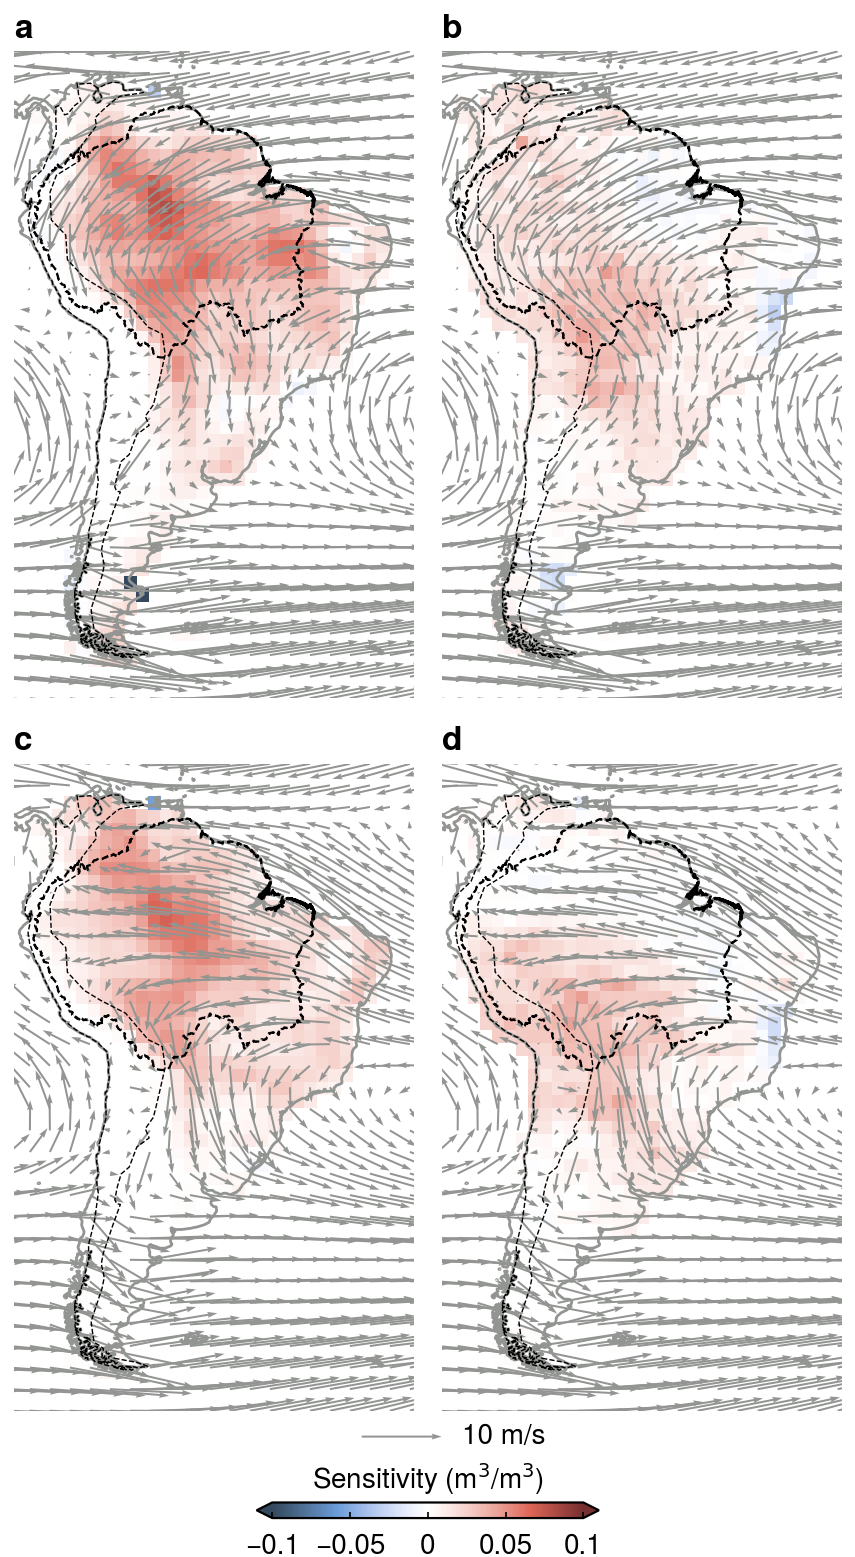

In [68]:
# Set map projection
proj = ccrs.PlateCarree()

# Define subplot arrangement grid (0 == empty, 1-4 == subplots A-D)
arrray = [
    [1, 2],  # Row 1: subplots A and B
    [3, 4],  # Row 2: subplots C and D  
    [0, 0]   # Row 3: empty (space for colorbar)
]
# Create figure with custom layout
fig = uplt.figure(refwidth=2, share=False, span=False, tight=True)
# Create subplots with specified projection and layout ratios
axs = fig.subplots(arrray, projection=proj, abc=True, width_ratios=[1, 1], height_ratios=[6, 6, 1])
# Format axes with geographic boundaries
axs.format(lonlim=lonlim, latlim=latlim, linewidth=0)

################################################
# Loop through each subplot (A-D)
for i in range(4):
    ax = axs[i]
    da = vlist[i]  # Get corresponding DataArray from input list
    
    # Create colored mesh plot of sensitivity values
    im = ax.pcolormesh(
        da.lon,
        da.lat,
        da.values,
        cmap='negpos',  # Diverging colormap
        discrete=False,
        transform=ccrs.PlateCarree(),
        vmin=-0.1, vmax=0.1,  # Fixed color range
    )
    
    # Plot Amazon basin border with dashed line
    amazon_border.plot(ax=ax, linewidth=0.8, color='none', linestyle='--', zorder=50)
    # Plot Andes mountains border
    geography_vector[geography_vector['NAME']=='ANDES'].plot(ax=ax, linewidth=0.5, color='none', linestyle='--', zorder=50, ec='k')
    
    # Add coastline feature
    ax.add_feature(cfeature.COASTLINE, edgecolor='grey', linewidth=1)
    
    # Select wind data based on season (DJF for top row, JJA for bottom row)
    if i in [0, 1]:
        pu0 = djf_mean_u  # DJF zonal wind
        pv0 = djf_mean_v  # DJF meridional wind
    else:
        pu0 = jja_mean_u  # JJA zonal wind
        pv0 = jja_mean_v  # JJA meridional wind

    # Add wind vector quiver plot
    qv = ax.quiver(pu0.longitude, pu0.latitude, pu0, pv0, 
                   transform=ccrs.PlateCarree(), vmin=0, vmax=15, color='grey',
                   scale=50,  # Arrow size scaling factor
                   width=0.005)  # Arrow width

# Create colorbar axis at bottom of figure
cax = fig.add_axes([0.3, 0.025, 0.4, 0.01], title='Sensitivity (m${^3}$/m${^3}$)', titlesize=10)
# Add horizontal colorbar
fig.colorbar(
    im,
    cax=cax,
    orientation='horizontal',
    extend='both',  # Extend arrows for out-of-range values
    ticks=[-0.1, -0.05, 0, 0.05, 0.1],
)

# Add wind speed reference key
handles = [ax.quiverkey(qv, 0, -0.04, 10, label='10 m/s', labelpos='E')]

# (Commented out) Text annotations for subplots
# axs[0].text(0,0.5,'DJF')
# axs[0].text(0,0,'Source influence')
# axs[1].text(0,0,'Sink sensitivity')
# axs[2].text(0,0.5,'JJA')

# Adjust layout to prevent overlapping elements
import matplotlib.pyplot as plt
plt.tight_layout()

In [10]:
# import os
# import json

# def search_in_ipynb(directory, keyword):
#     matches = []
#     for root, _, files in os.walk(directory):
#         for file in files:
#             if file.endswith('.ipynb'):
#                 filepath = os.path.join(root, file)
#                 try:
#                     with open(filepath, 'r', encoding='utf-8') as f:
#                         notebook = json.load(f)
#                         for cell in notebook.get('cells', []):
#                             if keyword.lower() in str(cell).lower():
#                                 matches.append(filepath)
#                                 break  # Found keyword, move to next file
#                 except Exception as e:
#                     print(f"Error reading {filepath}: {e}")
#     return matches

# # 设置搜索目录和关键词
# directory = './'  # 当前目录（可替换为你的目标路径）
# keyword = '850hpa'

# # 执行搜索
# results = search_in_ipynb(directory, keyword)

# # 打印结果
# print(f"Found '{keyword}' in the following notebooks:")
# for path in results:
#     print(f"- {path}")

Found '850hpa' in the following notebooks:
- ./AJ4-figs11-ss-growingseason.ipynb
- ./AJ3-figs4-v1-wind_rainfall.ipynb
- ./AJ3-Fig2-v2-growingseason.ipynb
- ./AJ3-fig25-v4-sig-asymmetry.ipynb
- ./.ipynb_checkpoints/AJ3-fig25-v4-sig-asymmetry-checkpoint.ipynb
- ./.ipynb_checkpoints/AJ3-Fig2-v2-growingseason-checkpoint.ipynb
